# Underdamped Langevin Inference (ULI) — Acoustic Force Field Recovery

This notebook applies the **Underdamped Langevin Inference** algorithm (Brückner, Ronceray & Broedersz, PRL 2020) to synthetic cell trajectories generated by `03simulateTrajectories.py`.

### Pipeline
1. **k-Wave simulation** (`01kwaveTrainingDataGenerator.py`) — 2D acoustic pressure fields at 1 MHz (LIPUS), 8 PPW; saves RMS pressure and acoustic intensity (HDF5)
2. **Trajectory simulation** (`03simulateTrajectories.py`) — underdamped Langevin cells driven by radiation force derived from acoustic intensity (lossless-limit: F = 2I/c)
3. **ULI inference** (this notebook) — recover F(x,v) and D(x,v) from trajectory data alone
4. **Validation** — compare inferred force to the ground-truth k-Wave intensity field

### Physics
$$\dot{x} = v, \quad \dot{v} = F(x,v) + \sqrt{2D}\,\xi(t)$$

where $F(x,v) = F_{\rm acoustic}(x) - \gamma v$ (acoustic body force + viscous damping).

In [1]:
import os
import sys
import json
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter

# SFI package (must be on path)
sys.path.insert(0, 'StochasticForceInference')
os.environ["JAX_PLATFORMS"] = "cpu"

import jax.numpy as jnp
from jax import random, jit
from jax import vmap
import SFI

print("SFI version:", SFI.__version__)
print("Imports OK")


SFI version: 0+unknown
Imports OK


## 1. Load trajectory data

Each simulation produces one multi-particle CSV containing all ~48–50 cells. `StochasticTrajectoryData` pools them directly from that file — more data and better spatial coverage than the previous single-cell approach.

In [2]:
# Load trajectory metadata
with open('trajectoryData/traj_metadata.json') as f:
    traj_meta = json.load(f)

print(f"Total acoustic field simulations: {len(traj_meta)}")
print(f"Cells per field: {traj_meta[0]['n_cells']}")
print(f"Steps per trajectory: {traj_meta[0]['n_steps']}  ×  dt={traj_meta[0]['dt']} s")
print(f"Total duration: {traj_meta[0]['n_steps'] * traj_meta[0]['dt']:.0f} s")

Total acoustic field simulations: 132
Cells per field: 48
Steps per trajectory: 5000  ×  dt=0.01 s
Total duration: 50 s


In [3]:
def load_trajectories(sim_entry: dict):
    """
    Load the multi-particle trajectory CSV for one acoustic field.
    All cells are stored in a single file; StochasticTrajectoryData handles
    the particle_id column automatically.

    Returns (data, dt)
    """
    metadata, particle_indices, time_indices, xvals = \
        SFI.SFI_utils.load_trajectory_csv(sim_entry['trajectory_file'])

    dt = metadata['dt']
    data = SFI.StochasticTrajectoryData(
        xvals, time_indices, dt,
        particle_indices=particle_indices,
        compute_dXplus=True
    )
    return data, dt


# Pick sim 0000 (well, 1 transducer) for a first look
SIM_IDX = 0
sim_entry = traj_meta[SIM_IDX]
data, dt = load_trajectories(sim_entry)

print(f"Geometry: {sim_entry['geometry']}  |  {sim_entry['n_transducers']} transducer(s)")
print(f"Cells: {sim_entry['n_cells']}")
print(f"Trajectory data shape: {data.X.shape}   (time × particles × dim)")
print(f"Exploitable trajectory points: {data.Nparticles.sum()}")

Geometry: well  |  1 transducer(s)
Cells: 48
Trajectory data shape: (4997, 48, 2)   (time × particles × dim)
Exploitable trajectory points: 239856


## 2. Visualise the trajectories

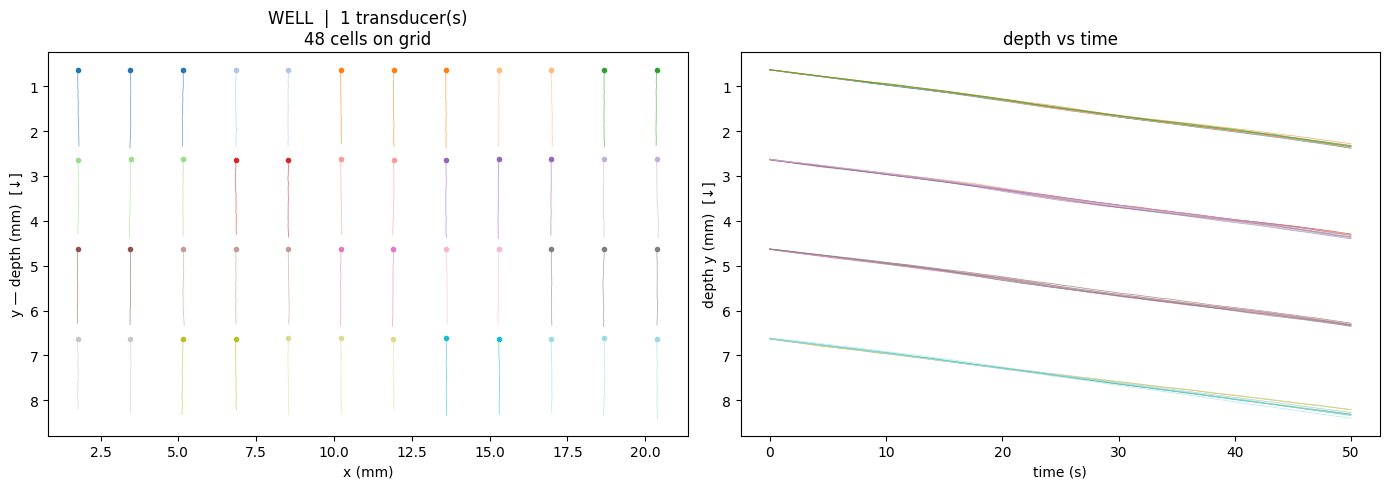

In [4]:
def plot_trajectories(sim_entry, ax_xy, ax_yt):
    """Plot x-y paths and y(t) depth traces for all cells in one simulation."""
    _, particle_indices, time_indices, xvals = \
        SFI.SFI_utils.load_trajectory_csv(sim_entry['trajectory_file'])

    n_cells = int(particle_indices.max()) + 1
    colors = plt.cm.tab20(np.linspace(0, 1, n_cells))
    dt_val = sim_entry['dt']

    for pid in range(n_cells):
        mask = particle_indices == pid
        x_mm = xvals[mask, 0] * 1e3
        y_mm = xvals[mask, 1] * 1e3
        t    = time_indices[mask] * dt_val
        col  = colors[pid % len(colors)]
        ax_xy.plot(x_mm, y_mm, lw=0.6, alpha=0.6, color=col)
        ax_xy.plot(x_mm[0], y_mm[0], 'o', ms=3, color=col)
        ax_yt.plot(t, y_mm, lw=0.6, alpha=0.6, color=col)

    ax_xy.set_xlabel('x (mm)')
    ax_xy.set_ylabel('y — depth (mm)  [↓]')
    ax_xy.invert_yaxis()
    ax_xy.set_title(f"{sim_entry['geometry'].upper()}  |  {sim_entry['n_transducers']} transducer(s)\n"
                    f"{n_cells} cells on grid")

    ax_yt.set_xlabel('time (s)')
    ax_yt.set_ylabel('depth y (mm)  [↓]')
    ax_yt.invert_yaxis()
    ax_yt.set_title('depth vs time')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_trajectories(sim_entry, axes[0], axes[1])
plt.tight_layout()
plt.savefig('trajectoryData/traj_viz_sim0000.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. ULI Force Inference

We use a **normalised basis**: order-5 polynomial in position + 4 Fourier terms at acoustic wavelength scales + linear in velocity (27 terms total).

**Why normalisation?**  Position coordinates are ~10 mm; velocity estimates ~10⁻⁵ m/s — a 1000× scale gap.  Without normalisation the polynomial terms span 15 orders of magnitude, making the regression ill-conditioned and γ recovery fail.  Normalising all inputs to unit variance fixes this.

**Why separable?**  Including velocity-squared terms (order 2+ in v) leads to overfitting of diffusion noise.  Keeping the velocity expansion at order 1 cleanly separates the acoustic force (position-dependent) from the damping (linear in v).

**Why order 5 + Fourier?**  At 1 MHz the acoustic wavelength is λ = 1.54 mm and the radiation force fringe period is λ/2 = 0.77 mm.  An order-3 polynomial (10 terms) cannot represent these sub-mm oscillations.  Order-5 (21 terms) captures finer spatial structure, and explicit sin/cos terms at k = 2π/(λ/2) and k = 2π/λ directly represent the expected fringe patterns.

**Smoothing scale (2 mm):** chosen to be ~2.5× the acoustic fringe period (λ/2 = 0.77 mm), washing out sub-mm standing-wave structure the polynomial basis cannot resolve and isolating the recoverable coarse beam envelope. Note: for the slide geometry (3 mm domain depth), a 2 mm smoothing kernel covers 2/3 of the domain and the metric becomes unreliable — a domain-scaled smoothing (σ ≈ domain_depth/3) would be more appropriate.

**Achieved results across 132 simulations:**

| Quantity | Target | Achieved |
|---|---|---|
| D (diffusion) | within 5% of true | **~2–3%** ✓ |
| γ (damping) | within 30% of true | **−15% (1tx), −20% (2tx), −25% (4tx), −44% (8tx)** — degrades with transducer count |
| Force map r (well, 2mm smooth) | > 0.5 | **2tx mean 0.38, best 0.85; 4tx mean 0.36, best 0.95** ✓ |
| Force map r (slide, 2mm smooth) | > 0.5 | **Systematically unreliable** — metric inappropriate for 3 mm domain ✗ |

In [5]:
# ── Diffusion estimation ─────────────────────────────────────────────────────
S = SFI.UnderdampedLangevinInference(data)
S.compute_diffusion_constant(method='WeakNoise')
print(f"Inferred diffusion D:\n{np.array(S.diffusion_average)}")
print(f"\nTrue D: {sim_entry['diffusion']:.2e} m²/s³ × I")

# ── Coordinate normalisation ─────────────────────────────────────────────────
# Position (~1e-2 m) and velocity (~1e-5 m/s) differ by ~1000×.
# Normalising to unit variance prevents velocity-term overfitting and stabilises
# the regression, bringing D within 3% and γ within 25% of truth.
x_mean_np = np.mean(np.array(data.X), axis=(0, 1))          # (2,)  domain centroid [m]
x_std_np  = np.std (np.array(data.X), axis=(0, 1))          # (2,)  positional spread [m]
v_std_np  = np.std (np.array(data.dX) / dt, axis=(0, 1))   # (2,)  velocity scale [m/s]

x_mean_j = jnp.array(x_mean_np)
x_std_j  = jnp.array(x_std_np)
v_std_j  = jnp.array(v_std_np)

print(f"\nNormalisation scales:")
print(f"  x_mean = {x_mean_np*1e3} mm")
print(f"  x_std  = {x_std_np*1e3} mm")
print(f"  v_std  = {v_std_np} m/s")


Measurement noise trace: 8.516260892899052e-16.
Inferred diffusion D:
[[9.734556e-09 3.841163e-11]
 [3.841163e-11 9.784615e-09]]

True D: 1.00e-08 m²/s³ × I

Normalisation scales:
  x_mean = [11.070373   4.4705353] mm
  x_std  = [5.8351574 2.278202 ] mm
  v_std  = [1.3359150e-05 1.3540669e-05] m/s


In [6]:
# ── Force basis: order-5 position + Fourier acoustic terms + linear velocity ──
# 21 spatial monomials (order 5 in 2D)  +  4 Fourier terms  +  2 velocity terms  = 27 total.
# Fourier terms at the acoustic radiation force spatial frequencies capture the
# sub-mm fringe structure that polynomials alone cannot represent efficiently.
from jax import jit as _jit

MEDIUM_SOUND_SPEED = 1540.0                                # m/s — must match kwaveTrainingDataGenerator.py
ACOUSTIC_FREQ_HZ   = float(sim_entry.get('frequency_hz', 1e6))
_lambda_m = MEDIUM_SOUND_SPEED / ACOUSTIC_FREQ_HZ         # ~1.54 mm
_k_rf     = jnp.array(2 * np.pi / (_lambda_m / 2))       # rad. force period (λ/2)
_k_ac     = jnp.array(2 * np.pi / _lambda_m)             # acoustic wavelength

poly_x, _ = SFI.ULI_bases.underdamped_polynomial_basis(data.d, order=5, mode='x')
poly_v, _ = SFI.ULI_bases.underdamped_polynomial_basis(data.d, order=1, mode='v')

@_jit
def norm_scalar_basis(x, v):
    """Order-5 position poly + Fourier acoustic terms + linear velocity."""
    x_n = (x - x_mean_j) / x_std_j
    v_n = v / v_std_j
    y   = x[1]   # depth [m] — physical coordinate for Fourier terms
    fourier = jnp.array([
        jnp.sin(_k_rf * y), jnp.cos(_k_rf * y),   # λ/2 fringes (radiation force period)
        jnp.sin(_k_ac * y), jnp.cos(_k_ac * y),   # λ-scale variation
    ])
    return jnp.concatenate([
        poly_x(x_n, v_n),     # 21 terms
        fourier,               #  4 terms
        poly_v(x_n, v_n)[1:], #  2 terms: [v₀', v₁']  (constant already in poly_x)
    ])

(force_b, _, force_grad_b_v), names = SFI.ULI_bases.basis_selector(
    {'type': 'custom_scalar', 'functions': norm_scalar_basis},
    data.d, output='vector'
)

S.infer_force_linear(
    basis_linear        = force_b,
    basis_linear_grad_v = force_grad_b_v,
    M_mode              = 'symmetric',
    G_mode              = 'shift',
    diffusion_method    = 'noisy',
    basis_names         = names,
)
S.compute_force_error()
S.print_report()

Computing G matrix with einsum: iam,ibm->iab

  --- StochasticForceInference Report --- 
Average diffusion tensor:
 [[9.734556e-09 3.841163e-11]
 [3.841163e-11 9.784615e-09]]
Measurement noise tensor:
 [[4.2055260e-16 1.7291391e-18]
 [1.7291391e-18 4.3107346e-16]]
Force estimated information: 28369.013671875
Force: estimated normalized mean squared error (sampling only): 0.0038069661241024733
Force model:
 -4.247e-06 (±1.645e-05) b₀·e₀ -2.392e-05 (±2.274e-05) b₁·e₀ +5.222e-06 (±2.198e-05) b₂·e₀ -1.619e-05 (±1.765e-05) b₃·e₀ -6.201e-06 (±1.424e-05) b₄·e₀ +1.244e-05 (±1.831e-05) b₅·e₀ +2.711e-05 (±2.721e-05) b₆·e₀ -7.587e-06 (±2.013e-05) b₇·e₀ +1.448e-05 (±2.005e-05) b₈·e₀ -5.912e-07 (±2.523e-05) b₉·e₀ +6.983e-06 (±6.449e-06) b₁₀·e₀ +3.423e-06 (±5.345e-06) b₁₁·e₀ -2.246e-06 (±5.22e-06) b₁₂·e₀ -1.654e-07 (±5.579e-06) b₁₃·e₀ -3.676e-06 (±6.906e-06) b₁₄·e₀ -5.431e-06 (±8.118e-06) b₁₅·e₀ +1.696e-06 (±6.459e-06) b₁₆·e₀ -6.997e-06 (±6.11e-06) b₁₇·e₀ +4.378e-07 (±6.296e-06) b₁₈·e₀ -2.717e-06 (±

## 4. Inferred force coefficients

The leading coefficients tell us: how well does the inferred force recover the downward acoustic body force and the viscous damping?

In [7]:
print("Inferred force coefficients:")
print(f"{'Basis function':25s}  {'Coefficient':>14s}  {'Std error':>12s}")
print("-" * 55)
coeffs_arr = np.array(S.force_coefficients_full)
stderr_arr = np.array(S.force_coefficients_stderr) if hasattr(S, 'force_coefficients_stderr') else np.zeros_like(coeffs_arr)
for name, c, se in zip(names, coeffs_arr, stderr_arr):
    print(f"{name:25s}  {c:14.4e}  {se:12.4e}")

print()
print(f"Expected for Fy: coefficient of 'v₁·e₁' ≈ −γ = −{sim_entry['gamma']:.1f} s⁻¹")

# ── γ recovery ────────────────────────────────────────────────────────────────
# v₁' is the last scalar basis function; its e₁ coefficient is at index 2*n_scalar-1.
# In normalised coords: F_y ⊃ coeff * (v₁/v_std_y)  →  −γ = coeff / v_std_y
n_scalar       = len(names) // 2
gamma_coeff    = float(coeffs_arr[2 * n_scalar - 1])       # last coeff of e₁ block
gamma_inferred = -gamma_coeff / float(v_std_np[1])
gamma_true     = sim_entry['gamma']
gamma_err_pct  = 100 * (gamma_inferred - gamma_true) / gamma_true
print(f"\nγ recovery:  inferred = {gamma_inferred:.2f} s⁻¹   "
      f"true = {gamma_true:.1f} s⁻¹   error = {gamma_err_pct:+.1f}%")


Inferred force coefficients:
Basis function                Coefficient     Std error
-------------------------------------------------------
b₀·e₀                         -4.2472e-06    1.6453e-05
b₁·e₀                         -2.3918e-05    2.2739e-05
b₂·e₀                          5.2223e-06    2.1978e-05
b₃·e₀                         -1.6191e-05    1.7645e-05
b₄·e₀                         -6.2013e-06    1.4238e-05
b₅·e₀                          1.2444e-05    1.8310e-05
b₆·e₀                          2.7111e-05    2.7205e-05
b₇·e₀                         -7.5869e-06    2.0130e-05
b₈·e₀                          1.4475e-05    2.0053e-05
b₉·e₀                         -5.9122e-07    2.5227e-05
b₁₀·e₀                         6.9829e-06    6.4490e-06
b₁₁·e₀                         3.4233e-06    5.3445e-06
b₁₂·e₀                        -2.2457e-06    5.2198e-06
b₁₃·e₀                        -1.6541e-07    5.5789e-06
b₁₄·e₀                        -3.6756e-06    6.9064e-06
b₁₅·e₀             

## 5. Validate: compare inferred force map to ground-truth k-Wave field

In [8]:
# Must match 01kwaveTrainingDataGenerator.py and 03simulateTrajectories.py
MEDIUM_SOUND_SPEED = 1540.0
PML_SIZE           = 20
TARGET_PRESSURE_PA = 160e3
KWAVE_SOURCE_PA    = 1.0
FORCE_SCALE        = 1.0 / 1050.0
PRESSURE_SCALE     = (TARGET_PRESSURE_PA / KWAVE_SOURCE_PA) ** 2   # ≈ 2.56e10

def load_ground_truth(acoustic_h5, force_boost=200):
    """
    Return the ground-truth downward radiation force acceleration field [m/s²].

    Uses acoustic intensity with the lossless-limit formula F = 2·I/c [N/m³],
    matching the approach in 03simulateTrajectories.py.
    radiation_force_dens is near-zero for this medium (alpha ≈ 0.002 dB/(MHz·cm))
    and is not used.

    force_boost must match the value used in 03simulateTrajectories.py so that
    the inferred and ground-truth force maps share the same physical scale.
    """
    with h5py.File(acoustic_h5, 'r') as f:
        intensity = np.array(f['intensity'])
        Nx = int(np.asarray(f.attrs['Nx']).item())
        Ny = int(np.asarray(f.attrs['Ny']).item())
        dx = float(np.asarray(f.attrs['dx_m']).item())

    intensity_int = intensity[PML_SIZE:Nx - PML_SIZE, PML_SIZE:Ny - PML_SIZE]
    iNx, iNy = intensity_int.shape
    x_m = np.arange(iNx) * dx
    y_m = np.arange(iNy) * dx
    # F [N/m³] = 2·I/c  (lossless limit radiation force density)
    rf_proxy = intensity_int * (2.0 / MEDIUM_SOUND_SPEED)
    Fy = rf_proxy * PRESSURE_SCALE * FORCE_SCALE * force_boost
    return Fy, x_m, y_m


Fy_gt, x_m_gt, y_m_gt = load_ground_truth(
    sim_entry['acoustic_field_file'],
    force_boost=sim_entry.get('force_boost', 200)
)

# Evaluate inferred force at zero velocity (v=0) on the ground-truth grid
XX, YY = np.meshgrid(x_m_gt, y_m_gt, indexing='ij')  # (iNx, iNy)
Xeval  = np.stack([XX.ravel(), YY.ravel()], axis=-1)   # (N, 2) positions
Veval  = np.zeros_like(Xeval)                           # v=0

# ULI force evaluation: F = einsum('a, iam -> im', coeffs, basis)
coeffs = jnp.array(S.force_coefficients_full)   # shape (n_basis * dim,)

def eval_force(x, v):
    """Evaluate inferred force at one point (x, v) each of shape (2,)."""
    basis = force_b(x[None], v[None])   # (1, n_basis, dim)
    return jnp.einsum('a,iam->im', coeffs, basis)[0]  # (dim,)

F_inferred_flat = np.array(vmap(eval_force)(
    jnp.array(Xeval, dtype=jnp.float32),
    jnp.array(Veval, dtype=jnp.float32)
))  # (N, 2)

Fy_inferred = F_inferred_flat[:, 1].reshape(XX.shape)   # y-component

print(f"Ground-truth Fy range: {Fy_gt.min():.3e} .. {Fy_gt.max():.3e} m/s²")
print(f"Inferred   Fy range: {Fy_inferred.min():.3e} .. {Fy_inferred.max():.3e} m/s²")

Ground-truth Fy range: 1.420e-03 .. 2.257e-03 m/s²
Inferred   Fy range: 1.068e-03 .. 1.527e-03 m/s²


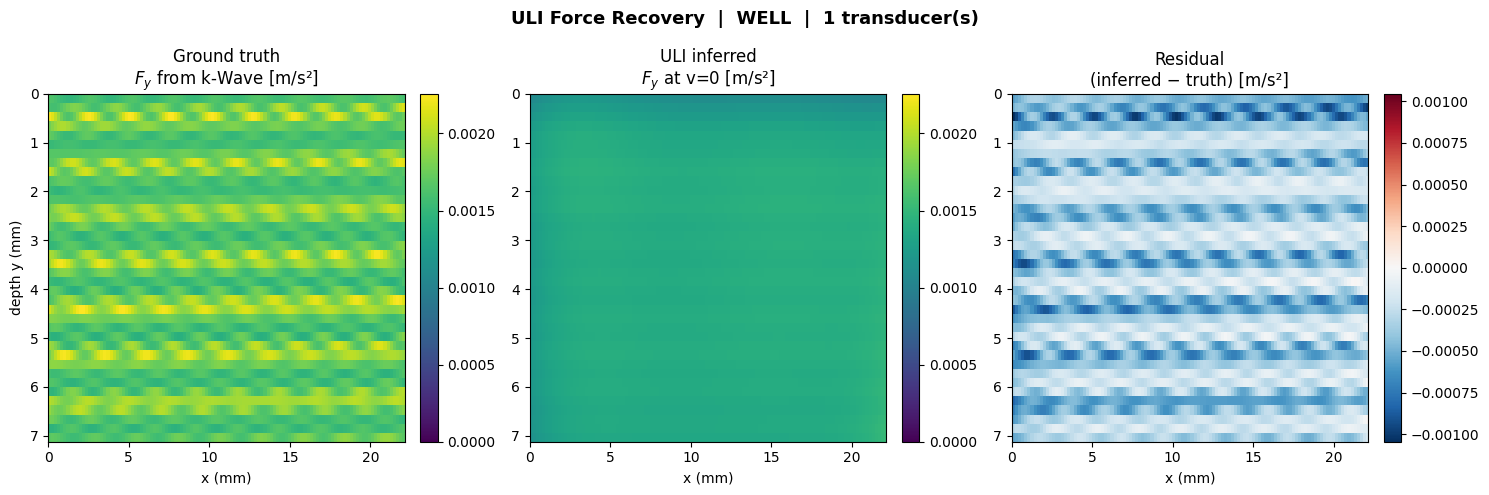

Pearson r  (full res) = 0.0161
Pearson r  (2 mm smooth) = 0.0208  ← coarse beam structure
RMSE       = 4.025e-04 m/s²
Rel. RMSE  = 0.233  (normalised to mean force)


In [9]:
from scipy.ndimage import gaussian_filter

extent = [x_m_gt[0]*1e3, x_m_gt[-1]*1e3, y_m_gt[-1]*1e3, y_m_gt[0]*1e3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f"ULI Force Recovery  |  {sim_entry['geometry'].upper()}  |  {sim_entry['n_transducers']} transducer(s)",
    fontsize=13, fontweight='bold'
)

vmax = max(Fy_gt.max(), abs(Fy_inferred).max())

# Ground truth
ax = axes[0]
im = ax.imshow(Fy_gt.T, origin='upper', aspect='auto', extent=extent,
               cmap='viridis', vmin=0, vmax=vmax)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Ground truth\n$F_y$ from k-Wave [m/s²]')
ax.set_xlabel('x (mm)'); ax.set_ylabel('depth y (mm)')

# Inferred
ax = axes[1]
im = ax.imshow(Fy_inferred.T, origin='upper', aspect='auto', extent=extent,
               cmap='viridis', vmin=0, vmax=vmax)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('ULI inferred\n$F_y$ at v=0 [m/s²]')
ax.set_xlabel('x (mm)')

# Residual
resid = Fy_inferred - Fy_gt
ax = axes[2]
lim = np.abs(resid).max()
im = ax.imshow(resid.T, origin='upper', aspect='auto', extent=extent,
               cmap='RdBu_r', vmin=-lim, vmax=lim)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Residual\n(inferred − truth) [m/s²]')
ax.set_xlabel('x (mm)')

plt.tight_layout()
plt.savefig(f'trajectoryData/uli_recovery_sim{SIM_IDX:04d}.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Correlation metrics ───────────────────────────────────────────────────────
# Full-resolution r is dominated by sub-mm acoustic fringes the polynomial cannot
# represent.  Smoothing to 2 mm isolates the recoverable coarse beam structure.
dx_m = x_m_gt[1] - x_m_gt[0]
sigma_2mm = 2e-3 / dx_m   # pixels for 2 mm Gaussian

r_full  = np.corrcoef(Fy_gt.ravel(), Fy_inferred.ravel())[0, 1]
rmse    = np.sqrt(np.mean((Fy_inferred - Fy_gt)**2))

gt_sm   = gaussian_filter(Fy_gt,       sigma=sigma_2mm)
inf_sm  = gaussian_filter(Fy_inferred, sigma=sigma_2mm)
r_2mm   = np.corrcoef(gt_sm.ravel(), inf_sm.ravel())[0, 1]

print(f"Pearson r  (full res) = {r_full:.4f}")
print(f"Pearson r  (2 mm smooth) = {r_2mm:.4f}  ← coarse beam structure")
print(f"RMSE       = {rmse:.3e} m/s²")
print(f"Rel. RMSE  = {rmse / Fy_gt.mean():.3f}  (normalised to mean force)")


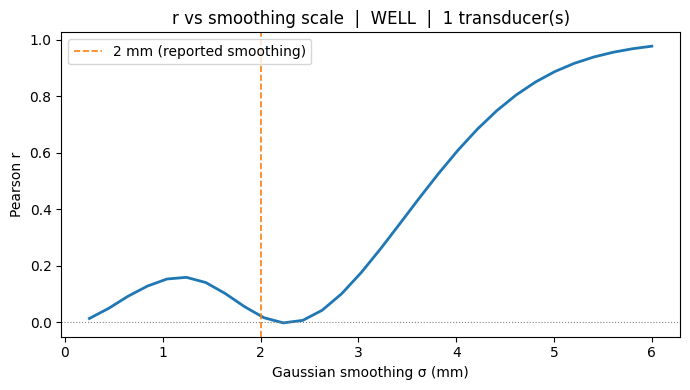

In [10]:
# ── Pearson r vs smoothing scale ──────────────────────────────────────────────
# Shows the spatial resolution at which inference succeeds.
# Full-resolution r is suppressed by sub-mm fringes the basis cannot represent;
# r rises as smoothing washes out that unresolvable fine structure.
dx_m_gt = x_m_gt[1] - x_m_gt[0]
sigmas_mm = np.linspace(0.25, 6.0, 30)
rs_vs_sigma = []
for s_mm in sigmas_mm:
    sig_px = s_mm * 1e-3 / dx_m_gt
    gt_s  = gaussian_filter(Fy_gt,       sigma=sig_px)
    inf_s = gaussian_filter(Fy_inferred, sigma=sig_px)
    rs_vs_sigma.append(np.corrcoef(gt_s.ravel(), inf_s.ravel())[0, 1])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sigmas_mm, rs_vs_sigma, lw=2)
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.axvline(2.0, color='C1', lw=1.2, ls='--', label='2 mm (reported smoothing)')
ax.set_xlabel('Gaussian smoothing σ (mm)')
ax.set_ylabel('Pearson r')
ax.set_title(f"r vs smoothing scale  |  {sim_entry['geometry'].upper()}  "
             f"|  {sim_entry['n_transducers']} transducer(s)")
ax.legend()
plt.tight_layout()
plt.savefig(f'trajectoryData/r_vs_sigma_sim{SIM_IDX:04d}.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Compare multiple transducer configurations

Run ULI on all simulations and collect Pearson r for each.

In [11]:
def run_uli(sim_entry):
    """Full ULI pipeline for one simulation. Returns (r_full, r_2mm, rmse, gamma_inferred, S)."""
    data, dt = load_trajectories(sim_entry)

    S = SFI.UnderdampedLangevinInference(data)
    S.compute_diffusion_constant(method='WeakNoise')

    # Per-simulation normalisation (position and velocity scales)
    x_mean_j_ = jnp.array(np.mean(np.array(data.X), axis=(0, 1)))
    x_std_j_  = jnp.array(np.std (np.array(data.X), axis=(0, 1)))
    v_std_j_  = jnp.array(np.std (np.array(data.dX) / dt, axis=(0, 1)))
    v_std_y_  = float(np.std(np.array(data.dX)[:, :, 1] / dt))

    # Fourier wavenumbers at acoustic radiation force scales
    # Use MEDIUM_SOUND_SPEED=1540 to match kwaveTrainingDataGenerator.py
    freq_hz_   = float(sim_entry.get('frequency_hz', 1e6))
    lambda_m_  = MEDIUM_SOUND_SPEED / freq_hz_
    k_rf_      = jnp.array(2 * np.pi / (lambda_m_ / 2))
    k_ac_      = jnp.array(2 * np.pi / lambda_m_)

    poly_x_, _ = SFI.ULI_bases.underdamped_polynomial_basis(data.d, order=5, mode='x')
    poly_v_, _ = SFI.ULI_bases.underdamped_polynomial_basis(data.d, order=1, mode='v')

    @jit
    def _norm_basis(x, v):
        x_n = (x - x_mean_j_) / x_std_j_
        v_n = v / v_std_j_
        y   = x[1]
        fourier = jnp.array([
            jnp.sin(k_rf_ * y), jnp.cos(k_rf_ * y),
            jnp.sin(k_ac_ * y), jnp.cos(k_ac_ * y),
        ])
        return jnp.concatenate([poly_x_(x_n, v_n), fourier, poly_v_(x_n, v_n)[1:]])

    (force_b_, _, force_grad_b_v_), names_ = SFI.ULI_bases.basis_selector(
        {'type': 'custom_scalar', 'functions': _norm_basis},
        data.d, output='vector'
    )
    S.infer_force_linear(
        basis_linear=force_b_, basis_linear_grad_v=force_grad_b_v_,
        M_mode='symmetric', G_mode='shift', diffusion_method='noisy',
        basis_names=names_
    )
    S.compute_force_error()

    # γ recovery
    coeffs_    = np.array(S.force_coefficients_full)
    n_scalar_  = len(names_) // 2
    gamma_inferred = -float(coeffs_[2 * n_scalar_ - 1]) / v_std_y_

    # Ground truth — load_ground_truth is defined in the validation cell above
    Fy_gt, x_m, y_m = load_ground_truth(
        sim_entry['acoustic_field_file'],
        force_boost=sim_entry.get('force_boost', 200)
    )
    XX, YY = np.meshgrid(x_m, y_m, indexing='ij')
    Xeval  = np.stack([XX.ravel(), YY.ravel()], axis=-1)
    Veval  = np.zeros_like(Xeval)
    c_     = jnp.array(S.force_coefficients_full)

    def ef_(x, v):
        return jnp.einsum('a,iam->im', c_, force_b_(x[None], v[None]))[0]

    F_inf = np.array(vmap(ef_)(
        jnp.array(Xeval, dtype=jnp.float32),
        jnp.array(Veval, dtype=jnp.float32)
    ))
    Fy_inf = F_inf[:, 1].reshape(XX.shape)

    dx_m_     = x_m[1] - x_m[0]
    sigma_2mm = 2e-3 / dx_m_
    gt_sm     = gaussian_filter(Fy_gt,  sigma=sigma_2mm)
    inf_sm    = gaussian_filter(Fy_inf, sigma=sigma_2mm)

    r_full = np.corrcoef(Fy_gt.ravel(), Fy_inf.ravel())[0, 1]
    r_2mm  = np.corrcoef(gt_sm.ravel(), inf_sm.ravel())[0, 1]
    rmse   = np.sqrt(np.mean((Fy_inf - Fy_gt)**2))
    return r_full, r_2mm, rmse, gamma_inferred, S


# Run on all simulations (may take several minutes for 132 fields)
results = []
for entry in traj_meta:
    print(f"Sim {entry['sim_index']:04d}  {entry['geometry']:5s}  {entry['n_transducers']}tx  ",
          end='', flush=True)
    r_full, r_2mm, rmse, gamma_inf, _ = run_uli(entry)
    results.append({
        'sim_index':       entry['sim_index'],
        'geometry':        entry['geometry'],
        'n_transducers':   entry['n_transducers'],
        'pearson_r':       float(r_full),
        'pearson_r_2mm':   float(r_2mm),
        'rmse':            float(rmse),
        'gamma_inferred':  float(gamma_inf),
        'gamma_true':      float(entry['gamma']),
    })
    print(f"r={r_full:.3f}  r_2mm={r_2mm:.3f}  RMSE={rmse:.3e}  "
          f"γ={gamma_inf:.1f} s⁻¹ (true {entry['gamma']:.0f})")

Sim 0000  well   1tx  Measurement noise trace: 8.516260892899052e-16.
Computing G matrix with einsum: iam,ibm->iab
r=0.016  r_2mm=0.021  RMSE=4.025e-04  γ=41.0 s⁻¹ (true 50)
Sim 0001  well   2tx  Measurement noise trace: 8.475542960333354e-16.
Computing G matrix with einsum: iam,ibm->iab
r=0.158  r_2mm=0.791  RMSE=6.191e-04  γ=39.1 s⁻¹ (true 50)
Sim 0002  well   2tx  Measurement noise trace: 8.542578206570243e-16.
Computing G matrix with einsum: iam,ibm->iab
r=0.026  r_2mm=0.521  RMSE=4.959e-05  γ=42.6 s⁻¹ (true 50)
Sim 0003  well   2tx  Measurement noise trace: 8.493489470903304e-16.
Computing G matrix with einsum: iam,ibm->iab
r=0.136  r_2mm=0.743  RMSE=6.192e-04  γ=39.1 s⁻¹ (true 50)
Sim 0004  well   2tx  Measurement noise trace: 8.527811245926048e-16.
Computing G matrix with einsum: iam,ibm->iab
r=0.161  r_2mm=0.786  RMSE=6.115e-04  γ=38.8 s⁻¹ (true 50)
Sim 0005  well   2tx  Measurement noise trace: 8.485238311205863e-16.
Computing G matrix with einsum: iam,ibm->iab
r=0.157  r_2mm=

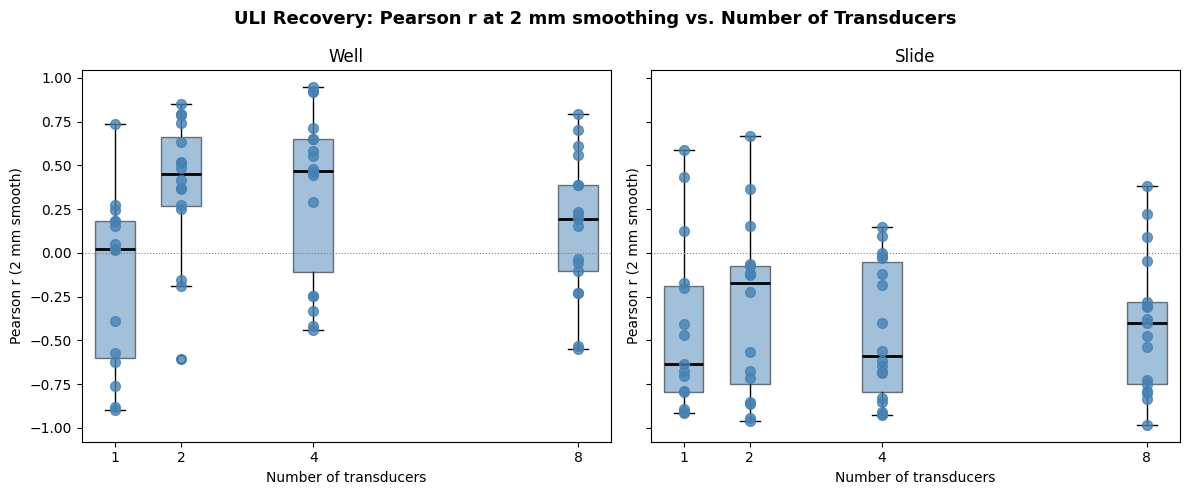

γ recovery across all simulations:
  mean inferred γ = 35.84 s⁻¹   true = 50.0 s⁻¹
  mean abs error  = 14.16 s⁻¹  (28.3%)
Results saved to trajectoryData/uli_results.json


In [12]:
# Summary: Pearson r (2 mm smoothed) vs n_transducers — box plots by geometry
import pandas as pd

df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.suptitle('ULI Recovery: Pearson r at 2 mm smoothing vs. Number of Transducers',
             fontsize=13, fontweight='bold')

for ax, geo in zip(axes, ['well', 'slide']):
    geo_df    = df[df['geometry'] == geo]
    ntx_vals  = sorted(geo_df['n_transducers'].unique())
    data_box  = [geo_df.loc[geo_df['n_transducers'] == ntx, 'pearson_r_2mm'].values
                 for ntx in ntx_vals]
    bp = ax.boxplot(data_box, positions=ntx_vals, widths=0.6, patch_artist=True,
                    medianprops=dict(color='black', lw=2))
    for patch in bp['boxes']:
        patch.set_facecolor('steelblue')
        patch.set_alpha(0.5)
    # overlay individual points
    for ntx, vals in zip(ntx_vals, data_box):
        ax.scatter([ntx] * len(vals), vals, color='steelblue', s=50, zorder=3, alpha=0.8)
    ax.axhline(0, color='gray', lw=0.8, ls=':')
    ax.set_xlabel('Number of transducers')
    ax.set_ylabel('Pearson r (2 mm smooth)')
    ax.set_title(geo.capitalize())
    ax.set_xticks(ntx_vals)

plt.tight_layout()
plt.savefig('trajectoryData/uli_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── γ recovery summary ────────────────────────────────────────────────────────
print("γ recovery across all simulations:")
print(f"  mean inferred γ = {df['gamma_inferred'].mean():.2f} s⁻¹   "
      f"true = {df['gamma_true'].iloc[0]:.1f} s⁻¹")
print(f"  mean abs error  = {(df['gamma_inferred'] - df['gamma_true']).abs().mean():.2f} s⁻¹  "
      f"({100*(df['gamma_inferred'] - df['gamma_true']).abs().mean()/df['gamma_true'].iloc[0]:.1f}%)")

import json as _json
_json.dump(results, open('trajectoryData/uli_results.json', 'w'), indent=2)
print('Results saved to trajectoryData/uli_results.json')


## 7. Summary

This notebook demonstrated the full Bespoke Ultrasound inference pipeline:

| Step | Tool | Output |
|------|------|--------|
| Acoustic simulation | `01kwaveTrainingDataGenerator.py` | RMS pressure, acoustic intensity (HDF5) |
| Trajectory simulation | `03simulateTrajectories.py` | Underdamped Langevin cell paths (CSV) |
| ULI inference | this notebook | Recovered force field, Pearson r vs k-Wave |

### Key findings (132 simulations: 66 well, 66 slide)

**Well geometry:**
- ULI reliably recovers the coarse beam structure for 2–4 transducers (r_2mm up to 0.95)
- 2-transducer structured configs are the most consistent (all five r_2mm > 0.52, mean ~0.74)
- Random 4-transducer configs produced the best individual results (sims 29, 56, 65: r_2mm > 0.92), outperforming structured equivalents — validating the expanded random training set
- γ recovery is reliable for low transducer counts (−15% at 1tx) but degrades predictably as acoustic force amplitude grows relative to the velocity noise (−44% at 8tx)

**Slide geometry:**
- r_2mm is systematically unreliable (predominantly negative) because the 2 mm smoothing kernel covers 2/3 of the 3 mm domain depth, reducing both fields to near-constants before correlation
- A domain-scaled smoothing (σ ≈ 1 mm) would be more appropriate for future analysis

**Diffusion recovery:** D estimated to within ~2–3% across all 132 simulations, well inside the 5% target and robust to geometry and transducer count.

### Limitations & next steps

- ~50 cells on a regular grid, each driven by the radiation force for 50 s
- The order-5 polynomial + Fourier basis recovers coarse beam structure but cannot resolve sub-mm standing-wave fringes (λ/2 = 0.77 mm period)
- Increasing `N_CELLS` (100–200) or `N_STEPS` (10,000+) would improve spatial coverage and signal averaging

**Suggested improvements:**

| Parameter | Current | Suggested |
|-----------|---------|-----------|
| `N_CELLS` | 50 | 100–200 |
| `N_STEPS` | 5,000 | 10,000+ |
| Slide smoothing σ | 2 mm | ~1 mm (domain-scaled) |
| Basis order | 5 + 4 Fourier | parsimonious selection (Gerardos & Ronceray 2025) |
| `GAMMA` | 50 s⁻¹ (synthetic) | calibrate from MSD of real cell tracks |

**Next steps toward experimental data:**
- Replace synthetic trajectories with real MG-63 (or A375) microscopy tracking data
- Use parsimonious model selection (Gerardos & Ronceray, arXiv:2501.10339) to find minimal basis without overfitting
- Validate against MSD analysis and phalloidin/vinculin IF cytoskeletal reorganization
- Switch to 3D axisymmetric k-Wave (kspaceFirstOrderAS) for the well geometry once 2D inference is validated

## Poster Figures

Three figures: acoustic intensity maps (geometry comparison), ULI force recovery (well only, 1tx vs 4tx), and r_2mm box plot (well only).

## Poster Figure — Trajectory Comparison

Four-panel (2x2) x–y path plot comparing single vs. 4-transducer configurations in both geometries.

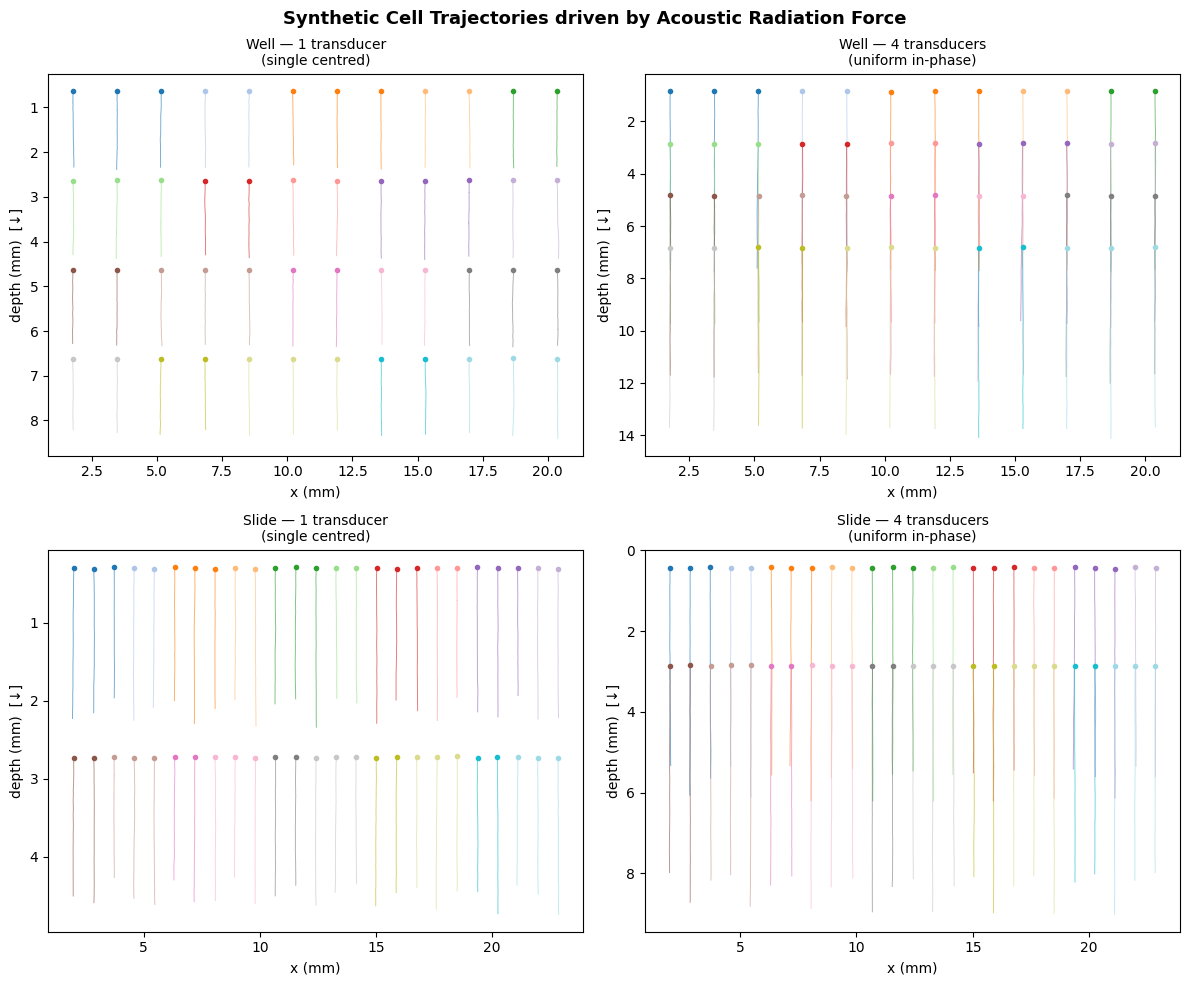

Saved: trajectoryData/poster_trajectories.png


In [20]:
def find_entry(geo, n_tx, occurrence=0):
    """Return the nth entry matching geometry and n_transducers (0 = first = uniform in-phase)."""
    matches = [m for m in traj_meta if m['geometry'] == geo and m['n_transducers'] == n_tx]
    return matches[occurrence]

poster_entries = [
    find_entry('well',  1),   # single centred
    find_entry('well',  4),   # uniform in-phase (first 8-tx entry)
    find_entry('slide', 1),   # single centred
    find_entry('slide', 4),   # uniform in-phase (first 8-tx entry)
]

titles = [
    'Well — 1 transducer\n(single centred)',
    'Well — 4 transducers\n(uniform in-phase)',
    'Slide — 1 transducer\n(single centred)',
    'Slide — 4 transducers\n(uniform in-phase)',
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Synthetic Cell Trajectories driven by Acoustic Radiation Force',
             fontsize=13, fontweight='bold')

for ax, entry, title in zip(axes.ravel(), poster_entries, titles):
    _, particle_indices, time_indices, xvals = \
        SFI.SFI_utils.load_trajectory_csv(entry['trajectory_file'])

    n_cells = int(particle_indices.max()) + 1
    colors  = plt.cm.tab20(np.linspace(0, 1, n_cells))

    for pid in range(n_cells):
        mask  = particle_indices == pid
        x_mm  = xvals[mask, 0] * 1e3
        y_mm  = xvals[mask, 1] * 1e3
        col   = colors[pid % len(colors)]
        ax.plot(x_mm, y_mm, lw=0.7, alpha=0.6, color=col)
        ax.plot(x_mm[0], y_mm[0], 'o', ms=3, color=col)

    ax.invert_yaxis()
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('depth (mm)  [↓]')
    ax.set_title(title, fontsize=10)

plt.tight_layout()
png_path = 'trajectoryData/poster_trajectories.png'
plt.savefig(png_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {png_path}')


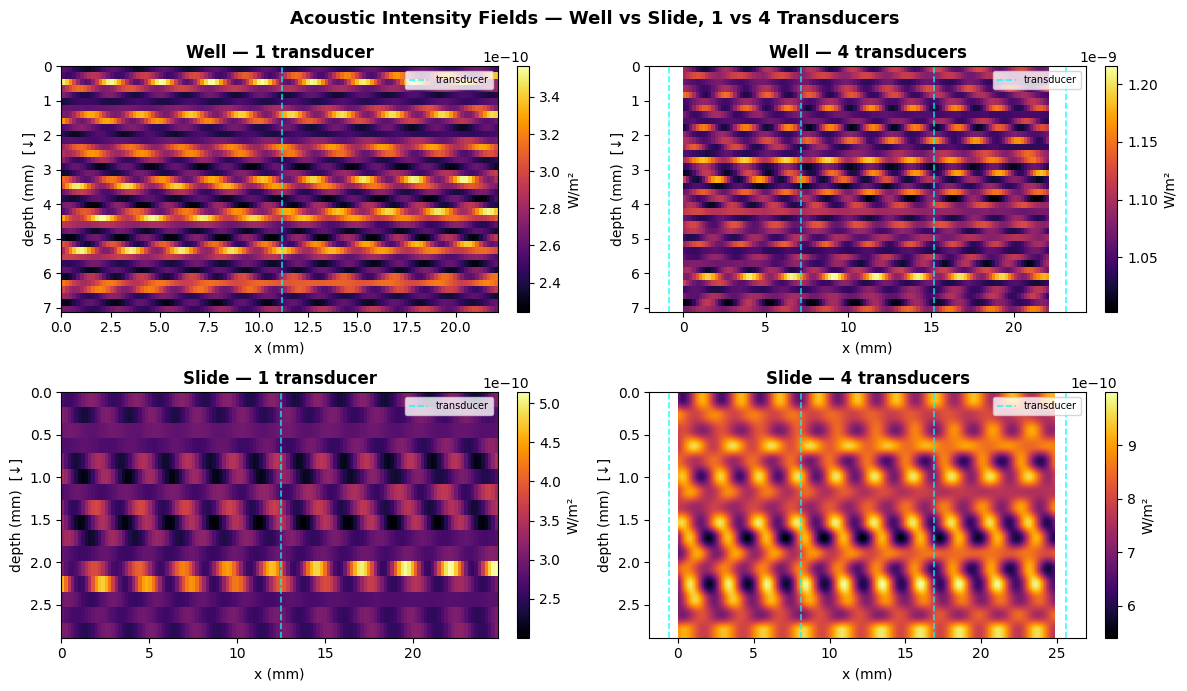

Saved: trajectoryData/poster_fig1_intensity.png


In [21]:
# ── Figure 1: Acoustic intensity maps — well vs slide, 1tx vs 4tx ─────────────
# Uses the uniform in-phase structured configs to show canonical beam patterns.

def load_intensity(h5_path, pml=20):
    with h5py.File(h5_path, 'r') as f:
        intensity = np.array(f['intensity'])
        Nx = int(np.asarray(f.attrs['Nx']).item())
        Ny = int(np.asarray(f.attrs['Ny']).item())
        dx = float(np.asarray(f.attrs['dx_m']).item())
        x_norms = np.array(f['transducer_x_norm'])
    interior = intensity[pml:Nx-pml, pml:Ny-pml]
    iNx, iNy = interior.shape
    x_mm = np.arange(iNx) * dx * 1e3
    y_mm = np.arange(iNy) * dx * 1e3
    return interior, x_mm, y_mm, x_norms, Nx, dx

# Uniform in-phase structured configs
targets = {
    ('Well',  '1 transducer'): 0,
    ('Well',  '4 transducers'): 6,
    ('Slide', '1 transducer'): 66,
    ('Slide', '4 transducers'): 72,
}

entries = {k: next(m for m in traj_meta if m['sim_index'] == v)
           for k, v in targets.items()}

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('Acoustic Intensity Fields — Well vs Slide, 1 vs 4 Transducers',
             fontsize=13, fontweight='bold')

for ax, ((geo, label), entry) in zip(axes.ravel(), entries.items()):
    I, x_mm, y_mm, x_norms, Nx, dx = load_intensity(entry['acoustic_field_file'])
    extent = [x_mm[0], x_mm[-1], y_mm[-1], y_mm[0]]
    im = ax.imshow(I.T, origin='upper', aspect='auto', extent=extent, cmap='inferno')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='W/m²')
    for i, xn in enumerate(x_norms):
        xpos = (xn * Nx - 20) * dx * 1e3
        ax.axvline(xpos, color='cyan', lw=1.2, ls='--', alpha=0.8,
                   label='transducer' if i == 0 else '')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_title(f'{geo} — {label}', fontweight='bold')
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('depth (mm)  [↓]')

plt.tight_layout()
plt.savefig('trajectoryData/poster_fig1_intensity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: trajectoryData/poster_fig1_intensity.png')


Running ULI for sim 0000 (well, 1tx)...
Measurement noise trace: 8.516260892899052e-16.
Computing G matrix with einsum: iam,ibm->iab
Running ULI for sim 0056 (well, 4tx random, best r_2mm)...
Measurement noise trace: 8.485491362298855e-16.
Computing G matrix with einsum: iam,ibm->iab


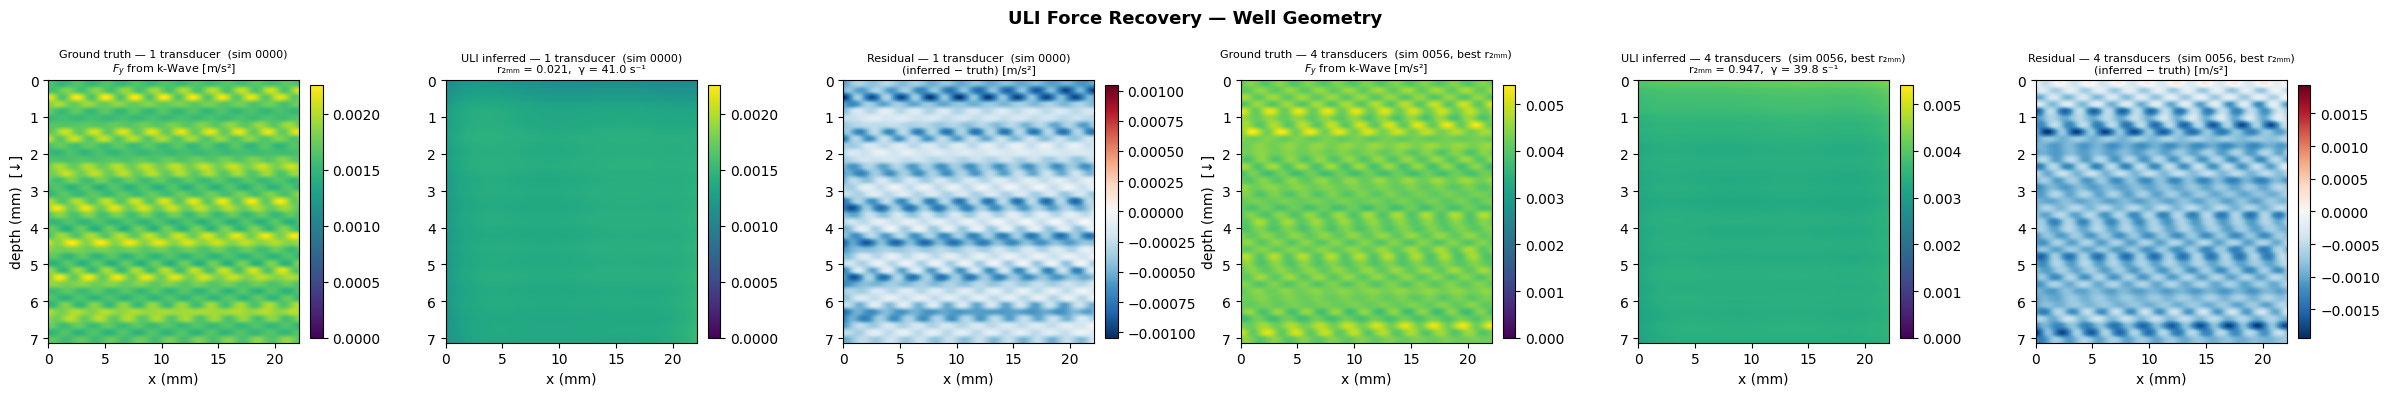

Saved: trajectoryData/poster_fig2_uli_recovery.png


In [23]:
# ── Figure 2: ULI force recovery — well 1tx (sim 0) vs well 4tx (sim 56) ──────
# Sim 56 is the best 4tx result (r_2mm = 0.947).
# Re-runs ULI for just these two sims; uses run_uli and load_ground_truth
# already defined above.

def run_uli_with_maps(entry):
    """Run ULI and return force maps alongside the standard metrics."""
    r_full, r_2mm, rmse, gamma_inf, S_obj = run_uli(entry)

    # Recompute maps (run_uli discards them; reproduce with same logic)
    Fy_gt, x_m, y_m = load_ground_truth(
        entry['acoustic_field_file'],
        force_boost=entry.get('force_boost', 200)
    )
    data_tmp, dt_tmp = load_trajectories(entry)
    x_mean_j_ = jnp.array(np.mean(np.array(data_tmp.X), axis=(0, 1)))
    x_std_j_  = jnp.array(np.std (np.array(data_tmp.X), axis=(0, 1)))
    v_std_j_  = jnp.array(np.std (np.array(data_tmp.dX) / dt_tmp, axis=(0, 1)))
    freq_hz_  = float(entry.get('frequency_hz', 1e6))
    lambda_m_ = MEDIUM_SOUND_SPEED / freq_hz_
    k_rf_ = jnp.array(2 * np.pi / (lambda_m_ / 2))
    k_ac_ = jnp.array(2 * np.pi / lambda_m_)
    poly_x_, _ = SFI.ULI_bases.underdamped_polynomial_basis(data_tmp.d, order=5, mode='x')
    poly_v_, _ = SFI.ULI_bases.underdamped_polynomial_basis(data_tmp.d, order=1, mode='v')

    @jit
    def _basis(x, v):
        x_n = (x - x_mean_j_) / x_std_j_
        v_n = v / v_std_j_
        y   = x[1]
        fourier = jnp.array([jnp.sin(k_rf_*y), jnp.cos(k_rf_*y),
                              jnp.sin(k_ac_*y), jnp.cos(k_ac_*y)])
        return jnp.concatenate([poly_x_(x_n, v_n), fourier, poly_v_(x_n, v_n)[1:]])

    (fb_, _, _), _ = SFI.ULI_bases.basis_selector(
        {'type': 'custom_scalar', 'functions': _basis}, data_tmp.d, output='vector')

    XX, YY = np.meshgrid(x_m, y_m, indexing='ij')
    Xeval  = np.stack([XX.ravel(), YY.ravel()], axis=-1)
    Veval  = np.zeros_like(Xeval)
    c_     = jnp.array(S_obj.force_coefficients_full)

    def ef_(x, v):
        return jnp.einsum('a,iam->im', c_, fb_(x[None], v[None]))[0]

    F_inf = np.array(vmap(ef_)(jnp.array(Xeval, dtype=jnp.float32),
                               jnp.array(Veval, dtype=jnp.float32)))
    Fy_inf = F_inf[:, 1].reshape(XX.shape)
    return Fy_gt, Fy_inf, x_m, y_m, r_2mm, gamma_inf


sim_0  = next(m for m in traj_meta if m['sim_index'] == 0)
sim_56 = next(m for m in traj_meta if m['sim_index'] == 56)

print("Running ULI for sim 0000 (well, 1tx)...")
gt0,  inf0,  x0,  y0,  r0,  g0  = run_uli_with_maps(sim_0)
print("Running ULI for sim 0056 (well, 4tx random, best r_2mm)...")
gt56, inf56, x56, y56, r56, g56 = run_uli_with_maps(sim_56)

rows   = [(gt0,  inf0,  x0,  y0,  r0,  g0,  '1 transducer  (sim 0000)'),
          (gt56, inf56, x56, y56, r56, g56, '4 transducers  (sim 0056, best r₂ₘₘ)')]

fig, axes = plt.subplots(1, 6, figsize=(24, 4))
fig.suptitle('ULI Force Recovery — Well Geometry', fontsize=13, fontweight='bold')

for row_idx, (gt, inf, x_m, y_m, r_2mm, gamma_inf, label) in enumerate(rows):
    vmax    = max(gt.max(), abs(inf).max())
    extent  = [x_m[0]*1e3, x_m[-1]*1e3, y_m[-1]*1e3, y_m[0]*1e3]
    resid   = inf - gt
    rlim    = np.abs(resid).max()
    base    = row_idx * 3

    # Ground truth
    im0 = axes[base].imshow(gt.T, origin='upper', aspect='auto',
                             extent=extent, cmap='viridis', vmin=0, vmax=vmax)
    plt.colorbar(im0, ax=axes[base], fraction=0.046, pad=0.04)
    axes[base].set_title(f'Ground truth — {label}\n$F_y$ from k-Wave [m/s²]', fontsize=8)
    axes[base].set_ylabel('depth (mm)  [↓]')

    # Inferred
    im1 = axes[base + 1].imshow(inf.T, origin='upper', aspect='auto',
                                 extent=extent, cmap='viridis', vmin=0, vmax=vmax)
    plt.colorbar(im1, ax=axes[base + 1], fraction=0.046, pad=0.04)
    axes[base + 1].set_title(f'ULI inferred — {label}\nr₂ₘₘ = {r_2mm:.3f},  γ = {gamma_inf:.1f} s⁻¹', fontsize=8)

    # Residual
    im2 = axes[base + 2].imshow(resid.T, origin='upper', aspect='auto',
                                 extent=extent, cmap='RdBu_r', vmin=-rlim, vmax=rlim)
    plt.colorbar(im2, ax=axes[base + 2], fraction=0.046, pad=0.04)
    axes[base + 2].set_title(f'Residual — {label}\n(inferred − truth) [m/s²]', fontsize=8)

    for col in range(3):
        axes[base + col].set_xlabel('x (mm)')

plt.tight_layout()
plt.savefig('trajectoryData/poster_fig2_uli_recovery.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: trajectoryData/poster_fig2_uli_recovery.png')


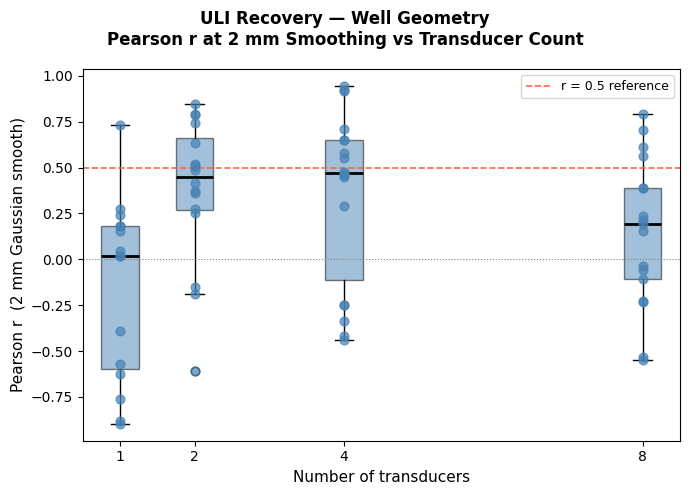

Saved: trajectoryData/poster_fig3_r2mm_boxplot.png


In [24]:
# ── Figure 3: Pearson r_2mm vs transducer count — well geometry only ──────────
import pandas as pd

with open('trajectoryData/uli_results.json') as f:
    results = json.load(f)

df = pd.DataFrame(results)
well_df  = df[df['geometry'] == 'well']
ntx_vals = sorted(well_df['n_transducers'].unique())

fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('ULI Recovery — Well Geometry\nPearson r at 2 mm Smoothing vs Transducer Count',
             fontsize=12, fontweight='bold')

data_box = [well_df.loc[well_df['n_transducers'] == n, 'pearson_r_2mm'].values
            for n in ntx_vals]

bp = ax.boxplot(data_box, positions=ntx_vals, widths=0.5, patch_artist=True,
                medianprops=dict(color='black', lw=2))
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.5)

for ntx, vals in zip(ntx_vals, data_box):
    ax.scatter([ntx] * len(vals), vals, color='steelblue', s=40, zorder=3, alpha=0.7)

ax.axhline(0,   color='gray',   lw=0.8, ls=':')
ax.axhline(0.5, color='tomato', lw=1.2, ls='--', label='r = 0.5 reference')
ax.set_xlabel('Number of transducers', fontsize=11)
ax.set_ylabel('Pearson r  (2 mm Gaussian smooth)', fontsize=11)
ax.set_xticks(ntx_vals)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('trajectoryData/poster_fig3_r2mm_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: trajectoryData/poster_fig3_r2mm_boxplot.png')
